In [ ]:
```markdown
# 02 — Data Cleaning & Preprocessing
## NeuroSpike: Global Solar Irradiance Forecasting

### What this notebook does
1. Loads all 10 raw city CSVs
2. Fixes the clearness_index missing values (recompute from GHI / clear_sky_GHI)
3. Handles remaining missing values
4. Removes physically impossible values
5. Adds local solar time correction per city
6. Normalizes / scales features
7. Saves clean processed CSVs ready for feature engineering
```

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import joblib

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))
import config

RAW_DIR       = os.path.join("..", config.RAW_DATA_DIR)
PROCESSED_DIR = os.path.join("..", config.PROCESSED_DATA_DIR)
PLOTS_DIR     = os.path.join("..", config.OUTPUTS_PLOTS)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,     exist_ok=True)

CITIES       = config.CITIES
DAYTIME_THR  = config.DAYTIME_THR     # 10 W/m²

print("✅ Imports ready")
print(f"   Raw dir       : {RAW_DIR}")
print(f"   Processed dir : {PROCESSED_DIR}")

✅ Imports ready
   Raw dir       : ..\data/raw
   Processed dir : ..\data/processed


In [2]:
city_dfs = {}

print("📂 Loading raw CSVs...\n")
for city in CITIES:
    path = os.path.join(RAW_DIR, f"{city}_raw.csv")
    df   = pd.read_csv(path, index_col="datetime", parse_dates=True)
    # Make sure index is tz-aware UTC
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    # Drop the city column (redundant)
    df.drop(columns=["city"], errors="ignore", inplace=True)
    city_dfs[city] = df
    print(f"  ✅ {city:<14}  shape={df.shape}  "
          f"dtype_ok={df.select_dtypes('number').shape[1]==8}")

print(f"\n📋 Total cities loaded : {len(city_dfs)}")
print(f"   Columns per city    : {list(city_dfs['riyadh'].columns)}")

📂 Loading raw CSVs...

  ✅ riyadh          shape=(26280, 8)  dtype_ok=True
  ✅ cairo           shape=(26280, 8)  dtype_ok=True
  ✅ istanbul        shape=(26280, 8)  dtype_ok=True
  ✅ new_delhi       shape=(26280, 8)  dtype_ok=True
  ✅ dubai           shape=(26280, 8)  dtype_ok=True
  ✅ london          shape=(26280, 8)  dtype_ok=True
  ✅ sydney          shape=(26280, 8)  dtype_ok=True
  ✅ tokyo           shape=(26280, 8)  dtype_ok=True
  ✅ los_angeles     shape=(26280, 8)  dtype_ok=True
  ✅ nairobi         shape=(26280, 8)  dtype_ok=True

📋 Total cities loaded : 10
   Columns per city    : ['GHI', 'temperature', 'wind_speed', 'humidity', 'clear_sky_ghi', 'precipitation', 'pressure', 'clearness_index']


In [3]:
def fix_clearness_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    Recompute clearness_index = GHI / clear_sky_ghi for ALL rows.
    NASA's ALLSKY_KT is ~48% missing because it's only defined
    when clear_sky_ghi > 0.  We recompute it ourselves.

    Rules:
      - Nighttime (clear_sky_ghi == 0)  → clearness_index = 0.0
      - Daytime                         → GHI / clear_sky_ghi, clipped [0, 1]
    """
    df = df.copy()
    csghi = df["clear_sky_ghi"].replace(0, np.nan)
    kt    = (df["GHI"] / csghi).clip(0.0, 1.0)
    kt    = kt.fillna(0.0)           # nighttime → 0
    df["clearness_index"] = kt
    return df

print("🔧 Fixing clearness_index for all cities...\n")
for city in city_dfs:
    before_missing = city_dfs[city]["clearness_index"].isna().mean() * 100
    city_dfs[city] = fix_clearness_index(city_dfs[city])
    after_missing  = city_dfs[city]["clearness_index"].isna().mean() * 100
    print(f"  {city:<14}  missing before={before_missing:.1f}%  →  after={after_missing:.1f}%")

print("\n✅ clearness_index recomputed for all cities")

🔧 Fixing clearness_index for all cities...

  riyadh          missing before=48.1%  →  after=0.0%
  cairo           missing before=48.5%  →  after=0.0%
  istanbul        missing before=48.0%  →  after=0.0%
  new_delhi       missing before=48.3%  →  after=0.0%
  dubai           missing before=48.1%  →  after=0.0%
  london          missing before=48.9%  →  after=0.0%
  sydney          missing before=49.2%  →  after=0.0%
  tokyo           missing before=48.1%  →  after=0.0%
  los_angeles     missing before=48.7%  →  after=0.0%
  nairobi         missing before=46.4%  →  after=0.0%

✅ clearness_index recomputed for all cities


In [4]:
def handle_missing(df: pd.DataFrame, city: str) -> pd.DataFrame:
    """
    Strategy per column:
      - GHI / clear_sky_ghi / clearness_index : fill 0 at night, interpolate day
      - All others                             : linear time interpolation then ffill/bfill
    """
    df = df.copy()
    total_before = df.isna().sum().sum()

    # Time-based interpolation for weather features
    weather_cols = ["temperature", "wind_speed", "humidity",
                    "precipitation", "pressure"]
    for col in weather_cols:
        df[col] = df[col].interpolate(method="time").ffill().bfill()

    # Solar features — interpolate only during daytime, 0 at night
    for col in ["GHI", "clear_sky_ghi", "clearness_index"]:
        df[col] = df[col].interpolate(method="time")
        df[col] = df[col].fillna(0.0)
        df[col] = df[col].clip(lower=0.0)   # no negatives

    total_after = df.isna().sum().sum()
    print(f"  {city:<14}  missing: {total_before} → {total_after}")
    return df


print("🧹 Handling missing values...\n")
for city in city_dfs:
    city_dfs[city] = handle_missing(city_dfs[city], city)

print("\n✅ All missing values resolved")

🧹 Handling missing values...

  riyadh          missing: 0 → 0
  cairo           missing: 0 → 0
  istanbul        missing: 0 → 0
  new_delhi       missing: 0 → 0
  dubai           missing: 0 → 0
  london          missing: 0 → 0
  sydney          missing: 0 → 0
  tokyo           missing: 0 → 0
  los_angeles     missing: 0 → 0
  nairobi         missing: 0 → 0

✅ All missing values resolved


In [5]:
# Physical bounds for each feature
BOUNDS = {
    "GHI"             : (0,    1400),    # W/m²  — max solar constant ~1361
    "temperature"     : (-70,  70),      # °C
    "wind_speed"      : (0,    100),     # m/s   — fastest recorded ~113 m/s
    "humidity"        : (0,    100),     # %
    "clear_sky_ghi"   : (0,    1400),    # W/m²
    "precipitation"   : (0,    500),     # mm/hr
    "pressure"        : (50,   110),     # kPa
    "clearness_index" : (0,    1),       # dimensionless
}

print("⚠️  Clipping physically impossible values...\n")
outlier_report = {}

for city, df in city_dfs.items():
    city_outliers = {}
    for col, (lo, hi) in BOUNDS.items():
        if col not in df.columns:
            continue
        n_out = ((df[col] < lo) | (df[col] > hi)).sum()
        if n_out > 0:
            city_outliers[col] = int(n_out)
        df[col] = df[col].clip(lo, hi)
    city_dfs[city] = df
    outlier_report[city] = city_outliers
    status = f"{sum(city_outliers.values())} values clipped" if city_outliers else "clean"
    print(f"  {city:<14}  {status}  {city_outliers if city_outliers else ''}")

print("\n✅ Physical bounds enforced on all cities")

⚠️  Clipping physically impossible values...

  riyadh          clean  
  cairo           clean  
  istanbul        clean  
  new_delhi       clean  
  dubai           clean  
  london          clean  
  sydney          clean  
  tokyo           2 values clipped  {'precipitation': 2}
  los_angeles     clean  
  nairobi         clean  

✅ Physical bounds enforced on all cities


In [6]:
# UTC offset in hours for each city (standard time, no DST)
UTC_OFFSETS = {
    "riyadh"      :  3,
    "cairo"       :  2,
    "istanbul"    :  3,
    "new_delhi"   :  5.5,
    "dubai"       :  4,
    "london"      :  0,
    "sydney"      : 10,
    "tokyo"       :  9,
    "los_angeles" : -8,
    "nairobi"     :  3,
}


def add_local_time(df: pd.DataFrame, utc_offset: float) -> pd.DataFrame:
    """
    Add a local_hour column (0–23) based on UTC offset.
    This is important — solar irradiance patterns follow LOCAL solar time,
    not UTC. Without this, models trained across cities get confused.
    """
    df = df.copy()
    local_index      = df.index + pd.Timedelta(hours=utc_offset)
    df["local_hour"] = local_index.hour
    df["utc_offset"] = utc_offset
    return df


print("🕐 Adding local time columns...\n")
for city, df in city_dfs.items():
    offset         = UTC_OFFSETS[city]
    city_dfs[city] = add_local_time(df, offset)
    sample_utc     = df.index[100]
    sample_local   = sample_utc + pd.Timedelta(hours=offset)
    print(f"  {city:<14}  UTC+{offset:<5}  "
          f"sample UTC={sample_utc.hour:02d}h → local={sample_local.hour:02d}h")

print("\n✅ Local time added for all cities")

🕐 Adding local time columns...

  riyadh          UTC+3      sample UTC=04h → local=07h
  cairo           UTC+2      sample UTC=04h → local=06h
  istanbul        UTC+3      sample UTC=04h → local=07h
  new_delhi       UTC+5.5    sample UTC=04h → local=09h
  dubai           UTC+4      sample UTC=04h → local=08h
  london          UTC+0      sample UTC=04h → local=04h
  sydney          UTC+10     sample UTC=04h → local=14h
  tokyo           UTC+9      sample UTC=04h → local=13h
  los_angeles     UTC+-8     sample UTC=04h → local=20h
  nairobi         UTC+3      sample UTC=04h → local=07h

✅ Local time added for all cities


In [7]:
FEATURE_COLS = [
    "GHI", "temperature", "wind_speed", "humidity",
    "clear_sky_ghi", "precipitation", "pressure",
    "clearness_index", "local_hour", "utc_offset"
]

print("💾 Saving processed CSVs...\n")
save_summary = []

for city, df in city_dfs.items():
    # Keep only feature columns (in order)
    df_clean = df[FEATURE_COLS].copy()

    # Final null check
    nulls = df_clean.isna().sum().sum()
    if nulls > 0:
        print(f"  ⚠️  {city} still has {nulls} nulls — force filling")
        df_clean = df_clean.ffill().bfill().fillna(0)

    # Save
    out_path = os.path.join(PROCESSED_DIR, f"{city}_processed.csv")
    df_clean.to_csv(out_path)

    save_summary.append({
        "city"       : city,
        "rows"       : len(df_clean),
        "cols"       : len(df_clean.columns),
        "nulls_left" : int(df_clean.isna().sum().sum()),
        "ghi_max"    : round(df_clean["GHI"].max(), 1),
        "kt_mean"    : round(df_clean["clearness_index"].mean(), 3),
    })
    print(f"  ✅ {city:<14}  rows={len(df_clean):,}  nulls={nulls}  → {out_path}")

summary_df = pd.DataFrame(save_summary).set_index("city")
print(f"\n📊 Processed summary:\n")
print(summary_df.to_string())

💾 Saving processed CSVs...

  ✅ riyadh          rows=26,280  nulls=0  → ..\data/processed\riyadh_processed.csv
  ✅ cairo           rows=26,280  nulls=0  → ..\data/processed\cairo_processed.csv
  ✅ istanbul        rows=26,280  nulls=0  → ..\data/processed\istanbul_processed.csv
  ✅ new_delhi       rows=26,280  nulls=0  → ..\data/processed\new_delhi_processed.csv
  ✅ dubai           rows=26,280  nulls=0  → ..\data/processed\dubai_processed.csv
  ✅ london          rows=26,280  nulls=0  → ..\data/processed\london_processed.csv
  ✅ sydney          rows=26,280  nulls=0  → ..\data/processed\sydney_processed.csv
  ✅ tokyo           rows=26,280  nulls=0  → ..\data/processed\tokyo_processed.csv
  ✅ los_angeles     rows=26,280  nulls=0  → ..\data/processed\los_angeles_processed.csv
  ✅ nairobi         rows=26,280  nulls=0  → ..\data/processed\nairobi_processed.csv

📊 Processed summary:

              rows  cols  nulls_left  ghi_max  kt_mean
city                                                  
r

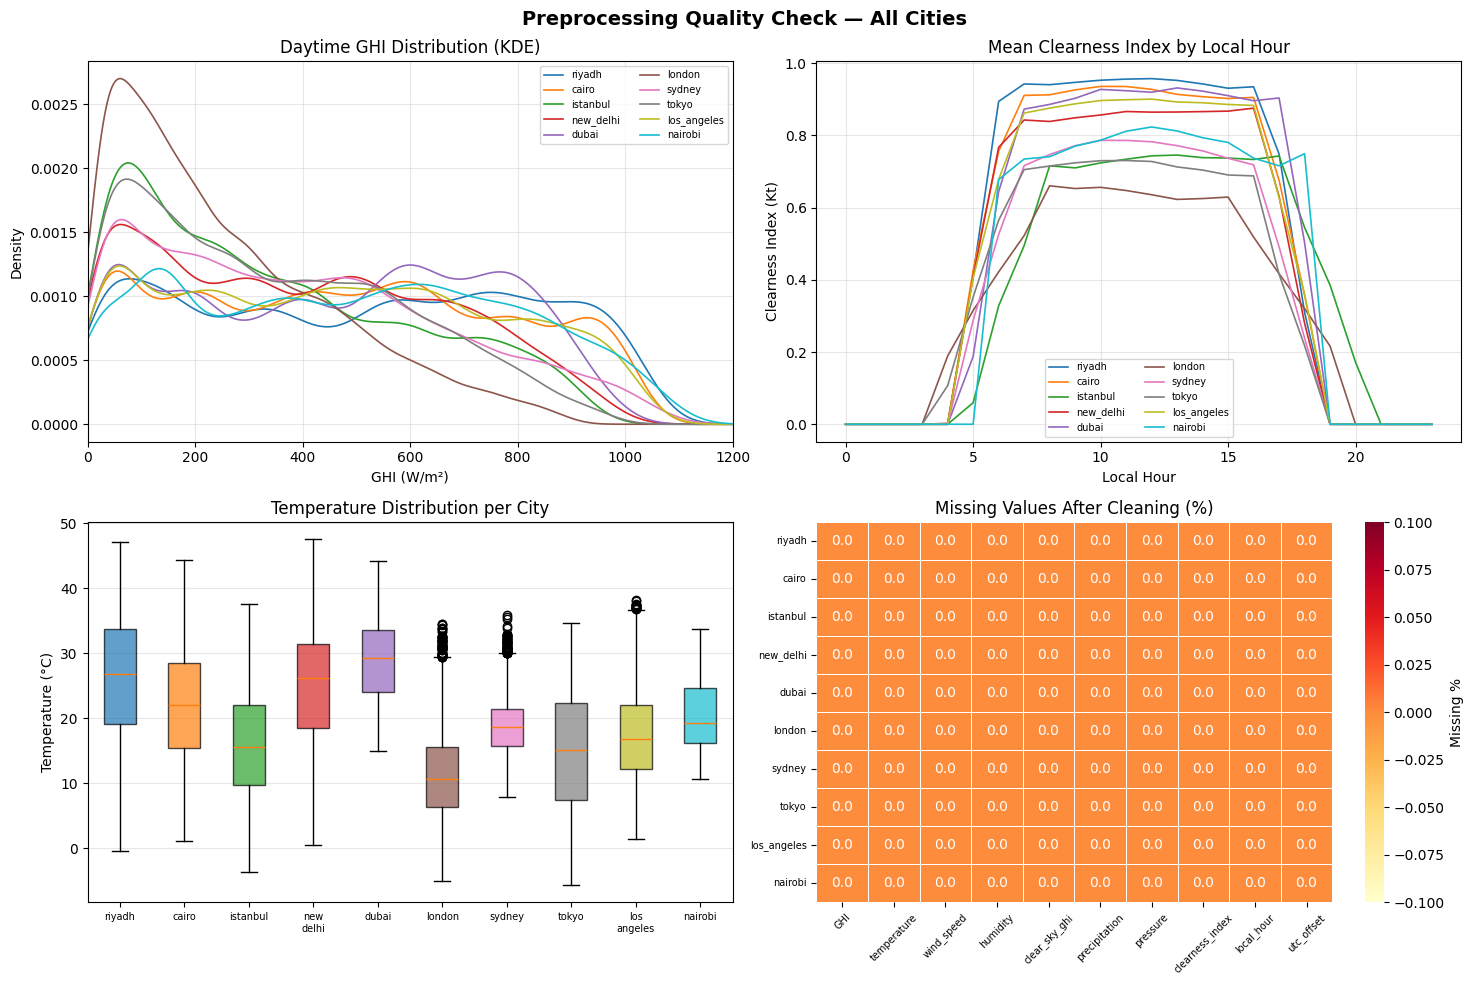

💾 Plot saved → ..\outputs/plots\02_preprocessing_quality.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Preprocessing Quality Check — All Cities", fontsize=14, fontweight="bold")

# ── Plot 1: GHI distribution per city ────────────────────────────
ax = axes[0, 0]
for city, df in city_dfs.items():
    daytime = df[df["GHI"] > DAYTIME_THR]["GHI"]
    daytime.plot.kde(ax=ax, label=city, linewidth=1.2)
ax.set_title("Daytime GHI Distribution (KDE)")
ax.set_xlabel("GHI (W/m²)")
ax.set_xlim(0, 1200)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Plot 2: Clearness index by local hour ─────────────────────────
ax = axes[0, 1]
for city, df in city_dfs.items():
    kt_by_hour = df.groupby("local_hour")["clearness_index"].mean()
    ax.plot(kt_by_hour.index, kt_by_hour.values, label=city, linewidth=1.2)
ax.set_title("Mean Clearness Index by Local Hour")
ax.set_xlabel("Local Hour")
ax.set_ylabel("Clearness Index (Kt)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Plot 3: Temperature range per city ───────────────────────────
ax = axes[1, 0]
temp_data  = [city_dfs[c]["temperature"].values for c in CITIES]
city_names = [c.replace("_", "\n") for c in CITIES]
bp = ax.boxplot(temp_data, labels=city_names, patch_artist=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(CITIES)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Temperature Distribution per City")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, alpha=0.3, axis="y")
ax.tick_params(axis="x", labelsize=7)

# ── Plot 4: Missing values heatmap after cleaning ────────────────
ax = axes[1, 1]
missing_matrix = pd.DataFrame({
    city: city_dfs[city][FEATURE_COLS].isna().mean() * 100
    for city in CITIES
}).T
sns.heatmap(
    missing_matrix, ax=ax, annot=True, fmt=".1f",
    cmap="YlOrRd", linewidths=0.5,
    cbar_kws={"label": "Missing %"}
)
ax.set_title("Missing Values After Cleaning (%)")
ax.tick_params(axis="x", labelsize=7, rotation=45)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, "02_preprocessing_quality.png")
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Plot saved → {plot_path}")

In [9]:
print("=" * 60)
print("  NOTEBOOK 02 — COMPLETE")
print("=" * 60)

proc_files = [f for f in os.listdir(PROCESSED_DIR) if f.endswith("_processed.csv")]
for f in sorted(proc_files):
    path = os.path.join(PROCESSED_DIR, f)
    df   = pd.read_csv(path, index_col=0)
    print(f"  📁 {f:<35}  {df.shape[0]:>6,} rows  ×  {df.shape[1]} cols")

print(f"\n  Features in each file : {FEATURE_COLS}")
print(f"\n  Ready for → 03_eda.ipynb")

  NOTEBOOK 02 — COMPLETE
  📁 cairo_processed.csv                  26,280 rows  ×  10 cols
  📁 dubai_processed.csv                  26,280 rows  ×  10 cols
  📁 istanbul_processed.csv               26,280 rows  ×  10 cols
  📁 london_processed.csv                 26,280 rows  ×  10 cols
  📁 los_angeles_processed.csv            26,280 rows  ×  10 cols
  📁 nairobi_processed.csv                26,280 rows  ×  10 cols
  📁 new_delhi_processed.csv              26,280 rows  ×  10 cols
  📁 riyadh_processed.csv                 26,280 rows  ×  10 cols
  📁 sydney_processed.csv                 26,280 rows  ×  10 cols
  📁 tokyo_processed.csv                  26,280 rows  ×  10 cols

  Features in each file : ['GHI', 'temperature', 'wind_speed', 'humidity', 'clear_sky_ghi', 'precipitation', 'pressure', 'clearness_index', 'local_hour', 'utc_offset']

  Ready for → 03_eda.ipynb
